In [ ]:
# Copyright 2025 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [ ]:
import dotenv
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import document_processing
import evaluate

# Reload modules to reflect recent edits.
import importlib
importlib.reload(document_processing)
importlib.reload(evaluate)


# Load environment variables.
dotenv.load_dotenv(dotenv_path=".env", override=True)
PROJECT_ID = os.environ.get("GEMINI_PROJECT_ID")
if not PROJECT_ID:
    raise ValueError("GEMINI_PROJECT_ID environment variable must be set.")
LOCATION = os.environ.get("GEMINI_LOCATION", "global")
IMAGE_PATHS = os.environ.get("IMAGE_PATHS", "")
IMAGE_PREFIX = os.environ.get("IMAGE_PREFIX", "")

# Set evaluation parameters.
EVAL_MODEL = "gemini-2.5-flash"
SAMPLE_SIZE = 200
RANDOM_STATE = 42


Using project ID: arielj-argolis-1


In [ ]:
# Run evaluation for document classification task. It will run on the specified 
# sample size and return the evaluation results and a DataFrame with detailed 
# information about each evaluated sample.

result, df = (
    evaluate.run_evaluation(
        project_id=PROJECT_ID, 
        location=LOCATION, 
        csv_path=IMAGE_PATHS,
        image_prefix=IMAGE_PREFIX,
        eval_model=EVAL_MODEL,
        sample_size=SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=True,
    )
)

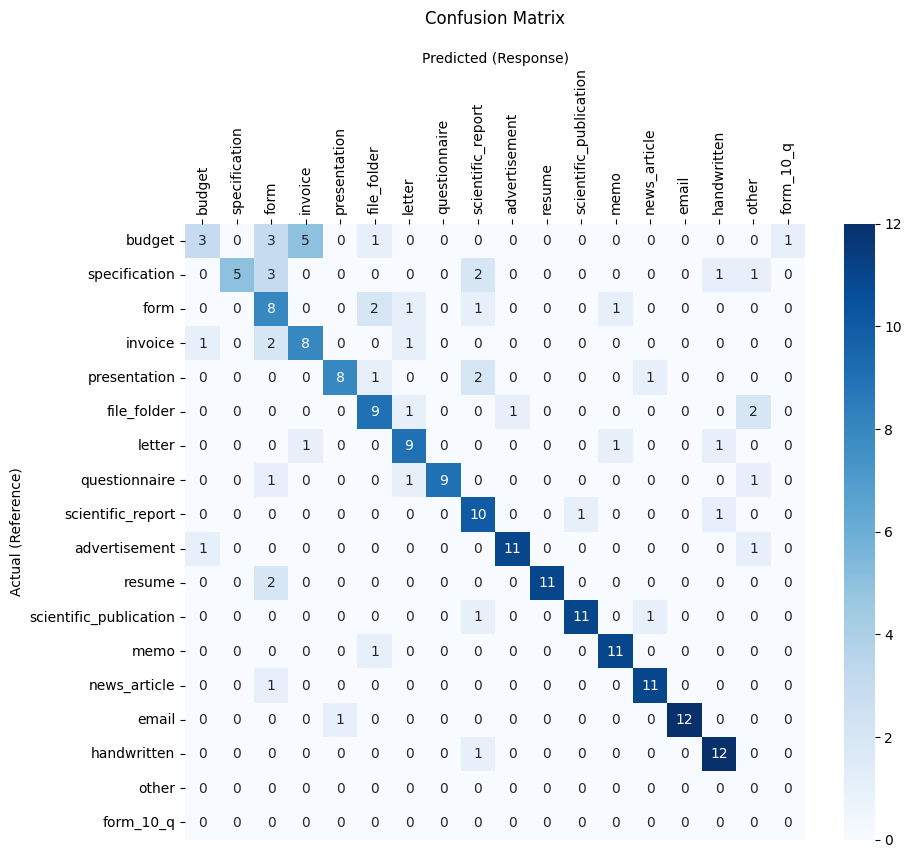

In [ ]:
# Create a confusion matrix that is ordered by the average exact match score for 
# each class.

# Extract the ordered list of classes.
avg_df = df.groupby('reference')['exact_match'].mean().reset_index()
avg_df = avg_df.sort_values(by='exact_match', ascending=True)

ordered_classes = avg_df['reference'].tolist()
extra_preds = [cls for cls in df['response'].unique() if cls not in ordered_classes]
full_order = ordered_classes + extra_preds

# Create and order the confusion matrix.
cm = pd.crosstab(df['reference'], df['response'])
cm_ordered = cm.reindex(index=full_order, columns=full_order, fill_value=0)

# Plot the confusion matrix.
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm_ordered, annot=True, fmt='d', cmap='Blues')

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.xticks(rotation=90)
plt.title('Confusion Matrix', pad=20)
plt.ylabel('Actual (Reference)')
plt.xlabel('Predicted (Response)')

plt.show()

In [ ]:
# Run evaluation for a specified set of target classes. This will allow us to 
# focus the evaluation on a subset of classes that are of particular interest.

SAMPLE_SIZE = 4

target_classes = [
    "budget", 
    "specification",
    "form",
    "invoice"
]
selected_result, selected_df = (
    evaluate.run_evaluation(
        project_id=PROJECT_ID, 
        location=LOCATION, 
        csv_path=IMAGE_PATHS,
        image_prefix=IMAGE_PREFIX,
        eval_model=EVAL_MODEL,
        sample_size=SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=True,
        classes=target_classes,
    )
)

print(selected_result.summary_metrics)
selected_df

    Based on the content of the document, classify it as one of the following classes.
    Output as JSON in the following format:
    "class": "class_name"


    Classes:

    {
    "specification": "Design requirements",
    "form": "Fill-in-the-blank document",
    "budget": "Financial plan",
    "invoice": "Request for payment"
}



/Users/arieljassan/Documents/projects/generative-ai/gemini/use-cases/entity-extraction/evaluate.py:81: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("reference", group_keys=False).apply(
Computing Metrics for Evaluation Dataset: 100%|██████████| 4/4 [00:01<00:00,  3.90it/s]


[AggregatedMetricResult(
  mean_score=0.75,
  metric_name='exact_match',
  num_cases_error=0,
  num_cases_total=4,
  num_cases_valid=4,
  stdev_score=0.5
)]


,img_path,response,reference,exact_match
0,gs://arielj-argolis-1-images/dataset/images/bu...,budget,budget,1.0
1,gs://arielj-argolis-1-images/dataset/images/fo...,specification,form,0.0
2,gs://arielj-argolis-1-images/dataset/images/in...,invoice,invoice,1.0
3,gs://arielj-argolis-1-images/dataset/images/sp...,specification,specification,1.0
